#### Importing Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

#### Importing the california house price dataset

In [17]:
from sklearn.datasets import fetch_california_housing
house_price_dataset = fetch_california_housing()

In [18]:
print(house_price_dataset)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

In [19]:
# Load the dataset into pandas data frame
house_price_dataframe = pd.DataFrame(house_price_dataset.data, columns = house_price_dataset.feature_names)

In [20]:
house_price_dataframe.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [21]:
# add the target(price) column to the DataFrame
house_price_dataframe['price'] = house_price_dataset.target

In [22]:
house_price_dataframe.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [23]:
# Rows and Columns
house_price_dataframe.shape

(20640, 9)

In [24]:
# Check for missing values
house_price_dataframe.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
price         0
dtype: int64

In [25]:
# Statistical measure of the dataset
house_price_dataframe.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#### Understanding the correlation between various features in the dataset

1. Positive Correlation
2. Negative Correlation

In [30]:
correlation = house_price_dataframe.corr()

<Axes: >

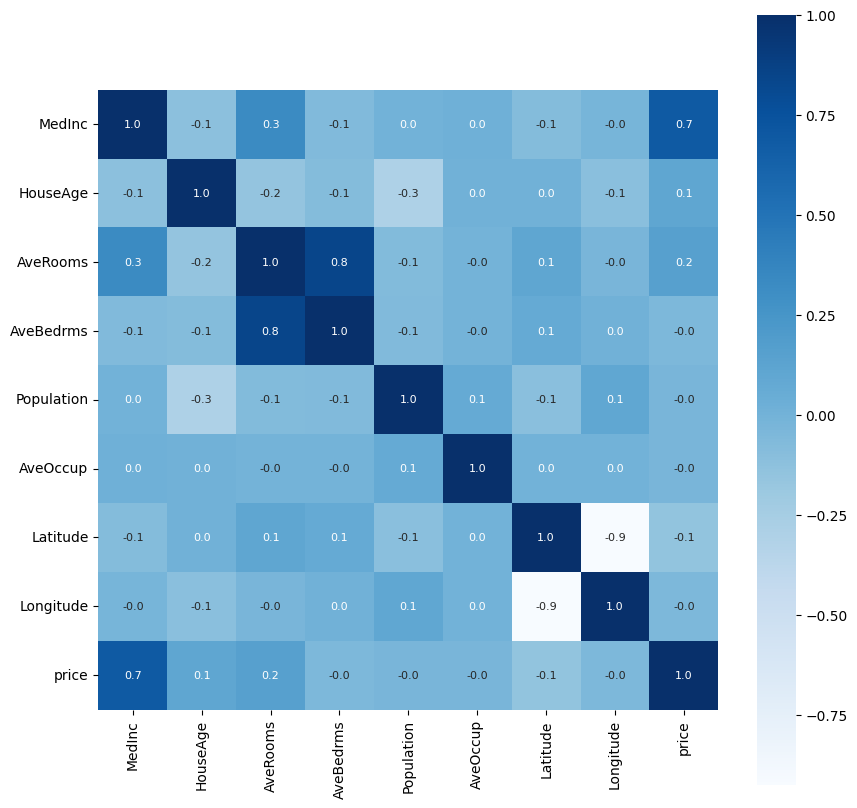

In [31]:
# Constructing a heatmap to understand the correlation
plt.figure(figsize =(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

#### Splitting the data and the target

In [32]:
x = house_price_dataframe.drop(['price'], axis = 1)
y = house_price_dataframe['price']

In [33]:
print(x)
print(y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

#### Splitting the data into training and test

In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 2)

In [35]:
print(x.shape, x_train.shape, x_test.shape)

(20640, 8) (16512, 8) (4128, 8)


In [36]:
print(y.shape, y_train.shape, y_test.shape)

(20640,) (16512,) (4128,)


#### Model Training
XGBoost Regressor

In [46]:
# load the model
model = XGBRegressor(
    max_depth=5,           # Limits how deep each tree can grow
    learning_rate=0.1,     # Slows down the learning process
    n_estimators=100,      # Sets the number of trees
    subsample=0.8          # Uses 80% of data per tree to improve generalization
)

In [47]:
# Train the model wiht x_train
model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### Evaluate the model
##### Prediction on training data

In [48]:
# Accuracy for prediction on training data
training_data_prediction = model.predict(x_train)

In [49]:
print(training_data_prediction)

[0.5272238  3.314288   0.6552262  ... 1.7844428  1.843895   0.80244595]


In [50]:
# R squared error
score_1 = metrics.r2_score(y_train, training_data_prediction)

# Mean Absolute error
score_2 = metrics.mean_absolute_error(y_train, training_data_prediction)

print("R squared error:", score_1)

print("Mean absolute error:", score_2)

R squared error: 0.8670942991667754
Mean absolute error: 0.29167057755434583


##### Visualizing the actual prices and predicted prices (Training data)

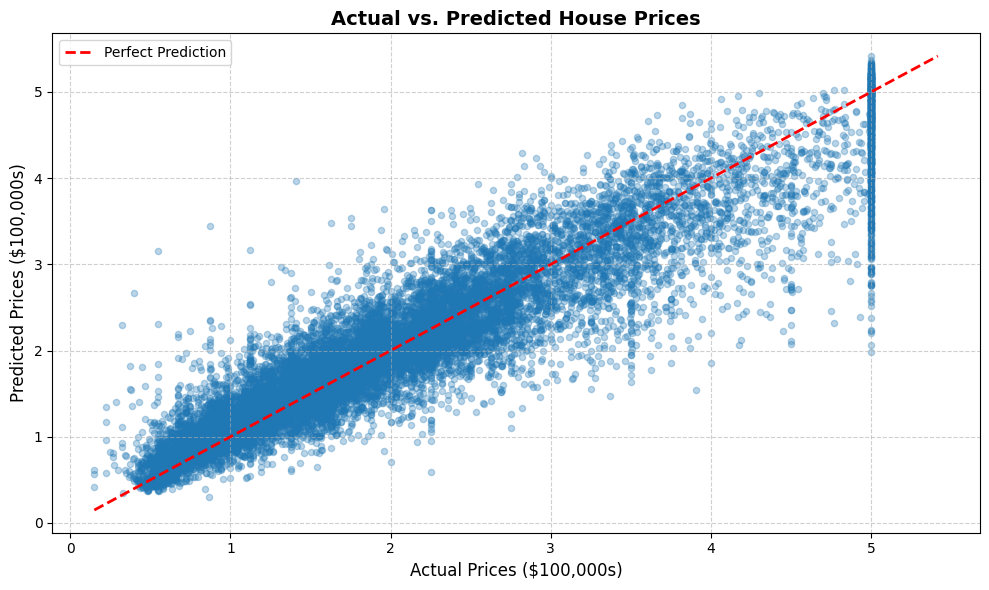

In [58]:
plt.figure(figsize=(10, 6))

# 1. Add alpha for transparency and reduce point size to see density
plt.scatter(y_train, training_data_prediction, alpha=0.3, s=20, color='#1f77b4')

# 2. Add a 'perfect prediction' diagonal line for reference
min_val = min(y_train.min(), training_data_prediction.min())
max_val = max(y_train.max(), training_data_prediction.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# 3. Enhance labels, title, and layout
plt.xlabel("Actual Prices ($100,000s)", fontsize=12)
plt.ylabel("Predicted Prices ($100,000s)", fontsize=12)
plt.title("Actual vs. Predicted House Prices", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

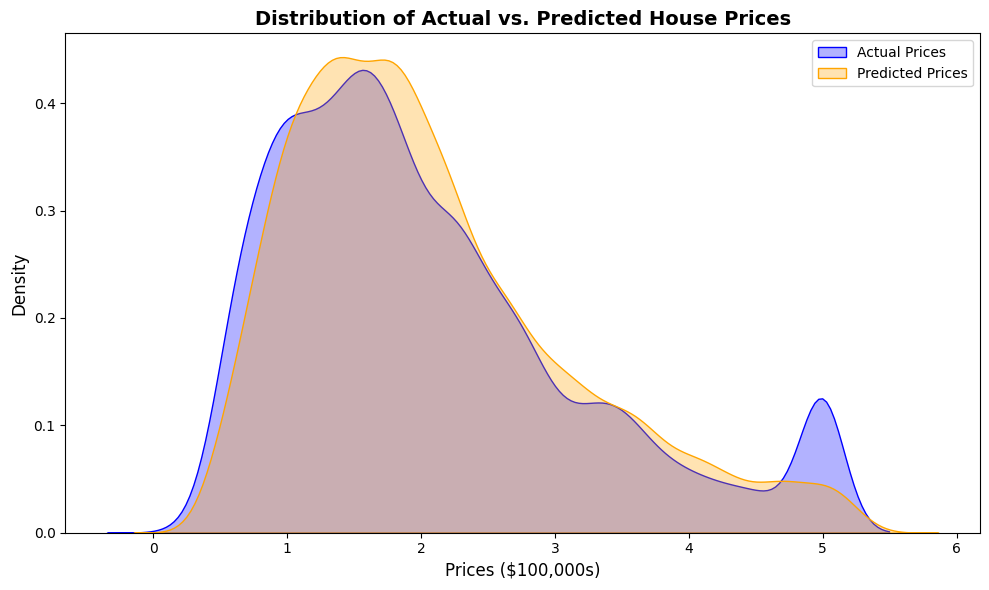

In [59]:
plt.figure(figsize=(10, 6))

# Plot the distribution of actual prices
sns.kdeplot(y_train, color='blue', label='Actual Prices', fill=True, alpha=0.3)

# Plot the distribution of predicted prices
sns.kdeplot(training_data_prediction, color='orange', label='Predicted Prices', fill=True, alpha=0.3)

plt.title("Distribution of Actual vs. Predicted House Prices", fontsize=14, fontweight='bold')
plt.xlabel("Prices ($100,000s)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.tight_layout()

plt.show()

Prediction on test data

In [51]:
# Accuracy for prediction on test data
test_data_prediction = model.predict(x_test)

In [52]:
print(test_data_prediction)

[2.9725976 1.7530285 0.9685714 ... 1.3945642 0.9246166 2.0180337]


In [53]:
# R squared error
score_3 = metrics.r2_score(y_test, test_data_prediction)

# Mean Absolute error
score_4 = metrics.mean_absolute_error(y_test, test_data_prediction)

print("R squared error:", score_3)

print("Mean absolute error:", score_4)

R squared error: 0.8232554953897598
Mean absolute error: 0.32308948767556006


##### Visualizing the actual prices and predicted prices (Test Data)

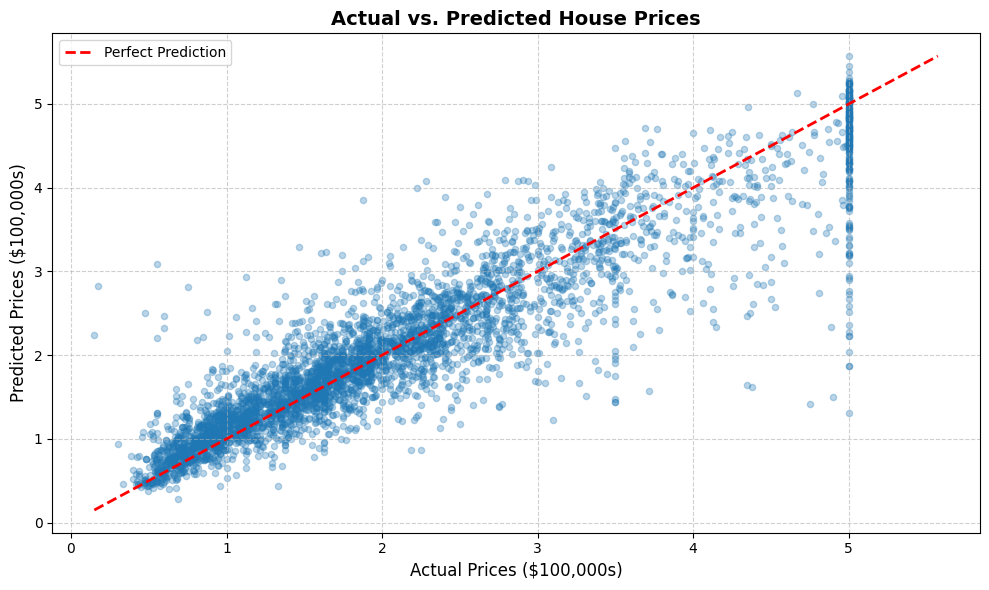

In [60]:
plt.figure(figsize=(10, 6))

# 1. Add alpha for transparency and reduce point size to see density
plt.scatter(y_test, test_data_prediction, alpha=0.3, s=20, color='#1f77b4')

# 2. Add a 'perfect prediction' diagonal line for reference
min_val = min(y_test.min(), test_data_prediction.min())
max_val = max(y_test.max(), test_data_prediction.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# 3. Enhance labels, title, and layout
plt.xlabel("Actual Prices ($100,000s)", fontsize=12)
plt.ylabel("Predicted Prices ($100,000s)", fontsize=12)
plt.title("Actual vs. Predicted House Prices", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

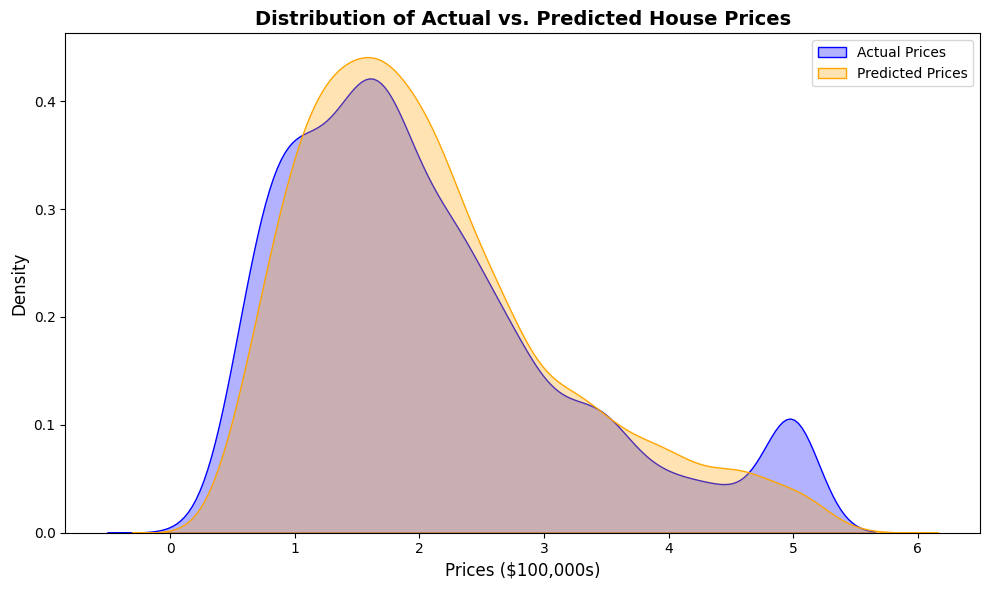

In [61]:
plt.figure(figsize=(10, 6))

# Plot the distribution of actual prices
sns.kdeplot(y_test, color='blue', label='Actual Prices', fill=True, alpha=0.3)

# Plot the distribution of predicted prices
sns.kdeplot(test_data_prediction, color='orange', label='Predicted Prices', fill=True, alpha=0.3)

plt.title("Distribution of Actual vs. Predicted House Prices", fontsize=14, fontweight='bold')
plt.xlabel("Prices ($100,000s)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.tight_layout()

plt.show()